In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Manually exploring the data and creating a classification function

In [5]:
# CKD: chronic kidney disease
ckd = Table.read_table('data/ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd.sample(5)

Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
57,80,1.025,0,0,normal,normal,notpresent,notpresent,119,17,1.2,135,4.7,15.4,42,6200,6.2,no,no,no,good,no,no,0
45,80,1.025,0,0,normal,normal,notpresent,notpresent,82,49,0.6,147,4.4,15.9,46,9100,4.7,no,no,no,good,no,no,0
29,80,1.02,0,0,normal,normal,notpresent,notpresent,70,16,0.7,138,3.5,13.7,54,5400,5.8,no,no,no,good,no,no,0
15,80,1.025,0,0,normal,normal,notpresent,notpresent,93,17,0.9,136,3.9,16.7,50,6200,5.2,no,no,no,good,no,no,0
55,90,1.01,2,1,abnormal,abnormal,notpresent,notpresent,273,235,14.2,132,3.4,8.3,22,14600,2.9,yes,yes,no,poor,yes,yes,1


In [7]:
shuffled_ckd = ckd.sample(with_replacement=False)
shuffled_ckd.num_rows

158

In [8]:
training_set = shuffled_ckd.take(np.arange(100))
test_set = shuffled_ckd.take(np.arange(100, 158))

In [9]:
training_set

Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
52,90,1.015,4,3,normal,abnormal,notpresent,notpresent,224,166,5.6,133,47,8.1,23,5000,2.9,yes,yes,no,good,no,yes,1
48,80,1.005,4,0,abnormal,abnormal,notpresent,present,133,139,8.5,132,5.5,10.3,36,6200,4,no,yes,no,good,yes,no,1
52,80,1.02,0,0,normal,normal,notpresent,notpresent,125,22,1.2,139,4.6,16.5,43,4700,4.6,no,no,no,good,no,no,0
64,60,1.01,4,1,abnormal,abnormal,notpresent,present,239,58,4.3,137,5.4,9.5,29,7500,3.4,yes,yes,no,poor,yes,no,1
23,80,1.025,0,0,normal,normal,notpresent,notpresent,111,34,1.1,145,4,14.3,41,7200,5,no,no,no,good,no,no,0
55,80,1.02,0,0,normal,normal,notpresent,notpresent,133,17,1.2,135,4.8,13.2,41,6800,5.3,no,no,no,good,no,no,0
30,80,1.02,0,0,normal,normal,notpresent,notpresent,131,38,1,147,3.8,14.1,45,9400,5.3,no,no,no,good,no,no,0
55,80,1.02,0,0,normal,normal,notpresent,notpresent,118,18,0.9,135,3.6,15.5,43,7200,5.4,no,no,no,good,no,no,0
56,80,1.025,0,0,normal,normal,notpresent,notpresent,139,15,1.2,135,5,14.8,42,5600,5.5,no,no,no,good,no,no,0
73,100,1.01,3,2,abnormal,abnormal,present,notpresent,295,90,5.6,140,2.9,9.2,30,7000,3.2,yes,yes,yes,poor,no,no,1


In [10]:
training_set.group('Class')

Class,count
0,74
1,26


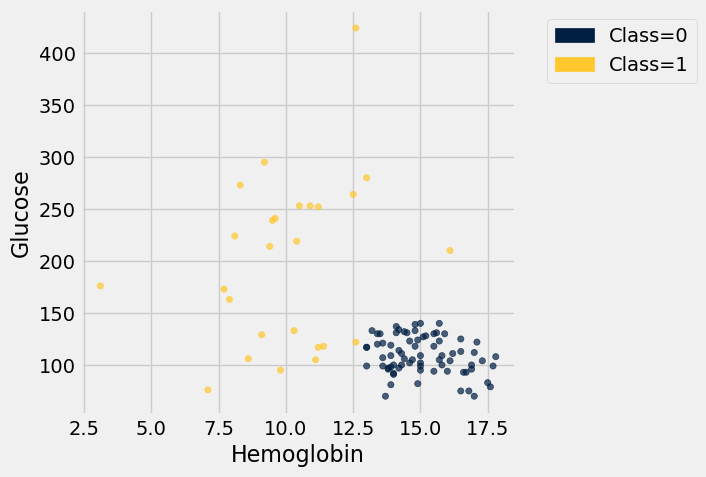

In [11]:
training_set.scatter('Hemoglobin', 'Glucose', group='Class')

In [15]:
min_hemoglobin_for_0 = training_set.where('Class', 0).column('Hemoglobin').min()
max_glucose_for_0 = training_set.where('Class', 0).column('Glucose').max()
min_hemoglobin_for_0, max_glucose_for_0

(13.0, 140)